### JURNAL FIKS
Mustafida (F1D024101126)

In [12]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt 

NumPy untuk memanipulasi gambar sebagai matriks angka, Matplotlib untuk menampilakn/visualisasi, cv2 untuk menyediakan cara cepat dalam mendeteksi gamabr

### Menampilkan citra Meledak
plt.imread digunakan untuk memuat file gambar ke dalam bentuk Array NumPy.

plt.imshow untuk meletakkan data array agar bisa di lihat

dilakukan pemanggilan gambar dari folder Assetd dengan nama cita "Meledak.png"

(720, 720, 3)


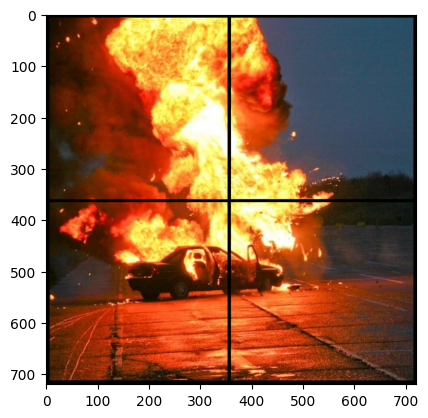

In [13]:
Meledak = plt.imread("Assets/Meledak.png")

plt.imshow(Meledak)
print(Meledak.shape)

### Pemisahan Gambar
fungsi_slicing digunakan untuk memisahkan gambar menjadi 4 bagian

karna citra sebelumnya masih dalam 1 gambar sehingga kita membagi gambar nya, dan kemudian nanti di satukan lagi.

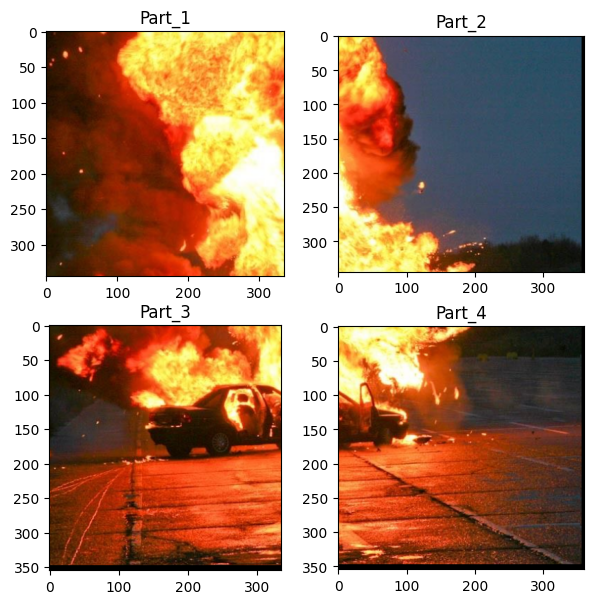

In [14]:
def slicing (gambar, a, b, mode='H'):
    return gambar[a:b, :] if mode == 'H' else gambar [:, a:b]

cut1 = slicing (Meledak, 15, 360)
gambar_1 = slicing(cut1, 15, 350, 'V')
gambar_2 = slicing(cut1, 360, 720, 'V')

cut2 = slicing (Meledak, 365, 720)
gambar_3 = slicing(cut2, 15, 350, 'V')
gambar_4 = slicing(cut2, 360, 720, 'V')

plt.figure(figsize=(7,7))

plt.subplot(2, 2, 1)
plt.imshow (gambar_1)
plt.title("Part_1")

plt.subplot(2, 2, 2)
plt.imshow (gambar_2)
plt.title("Part_2")

plt.subplot(2, 2, 3)
plt.imshow (gambar_3)
plt.title("Part_3")

plt.subplot(2, 2, 4)
plt.imshow (gambar_4)
plt.title("Part_4")
plt.show()

### Penggabungan
Fungsi merge_image ini bekerja dengan cara menggabungkan dua array citra menjadi satu, diinisialisasi menggunakan np.zeros, di mana orientasi 'H' menggabungkan gambar secara horizontal dan orientasi 'W' di gunakan secara vertikal. citra grayscale maupun berwarna (RGB) dengan mengecek dimensi shape, serta menggunakan koordinat slicing untuk menempelkan masing-masing citra ke posisi yang tepat pada matriks gabungan. Namun, pada baris terakhir, pemanggilan merge_image(gabungan1, gabungan2, 'W') akan mengeksekusi blok else (vertikal) karena parameter yang dimasukkan bukan 'H', sehingga menghasilkan satu gambar besar yang terdiri dari empat citra berbeda yang disusun dalam format dua baris dan dua kolom.

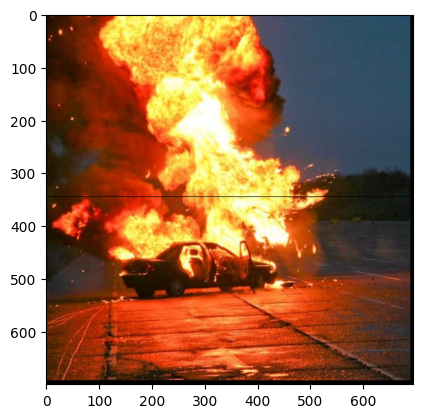

In [15]:
def merge_image(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0])      # .shape ukuran, 0 = tinggi  
        lebar_total = citra1.shape[1] + citra2.shape[1] 
        if len(citra1.shape) == 2:      # grayscale
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) # datatype menentukan rentang warna
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype)  #np.seros kyk wadah yg kosong 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0],  0:citra2.shape[1]] = citra2 
    return gabungan 

gabungan1 = merge_image(gambar_1, gambar_2, 'H')
gabungan2 = merge_image(gambar_3, gambar_4, 'H')
merge = merge_image(gabungan1, gabungan2, 'W')
plt.imshow(merge)
plt.show()

### Grayscale
memberikan warna abu pada citra yang sudah di gabungkan tadi, di buat Grayscale dulu agar nanti bisa di lakukan ekualisasi, yaitu dengan menajamkan citra.

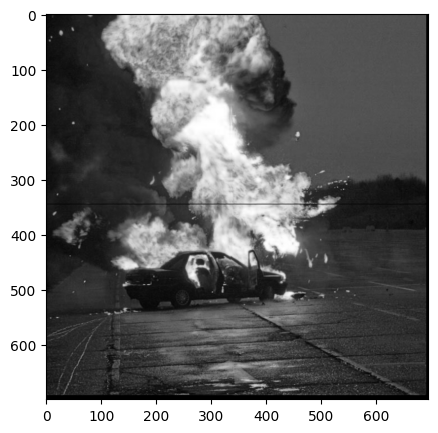

In [16]:
gc1 = cv.cvtColor(merge, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(gc1, cmap="gray")

### Ekualisasi Histogram Sebelum dan Sesudah
ekualisasi histogram bekerja dengan cara mendistribusikan ulang nilai intensitas piksel yang menumpuk di satu area sempit menjadi tersebar merata ke seluruh rentang derajat keabuan (0–255). Sebelum ekualisasi, citra cenderung memiliki kontras rendah sehingga tampak kusam atau gelap akibat histogram yang terlalu rapat, sedangkan setelah ekualisasi, perbedaan intensitas antar piksel diperlebar melalui perhitungan CDF sehingga citra tampil lebih tajam dengan detail yang jauh lebih jelas terlihat.

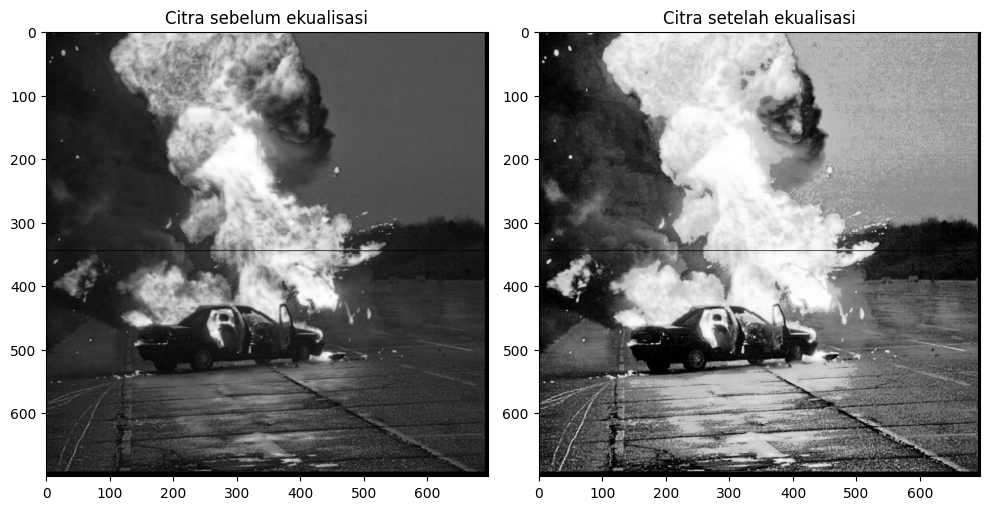

In [17]:
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)  # membuat di array, ada 256 slot
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int) # np.zeros_like ngambil semua/otomatis
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

gabung = (gc1 * 255).astype(np.uint8) # mengubah typedata

panjang, lebar = gabung.shape       # atribut / kumpulan angka yg ada di dlm kurung
hasil = ekualisasi_histogram(gabung)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gabung, cmap='gray')
plt.title("Citra sebelum ekualisasi")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title("Citra setelah ekualisasi")
plt.tight_layout()
plt.show()

Kedua citra di atas adalah citra sebelum di lakukan ekualisasi/penajaman dan setelah di lakukkannya ekualisasi, terlihat ada perbedaan yang menonjol yang dimana gambar pertama di bagiann kiri masih blur/buram, dan setelah di lakukannya ekualisasi dengan menggunakan fungsi ekualisasi_histrogram, terlihat perbedaannya menjadi lebih tajam citra nya.

### histogram sebelum dan sesudah ekualisasi

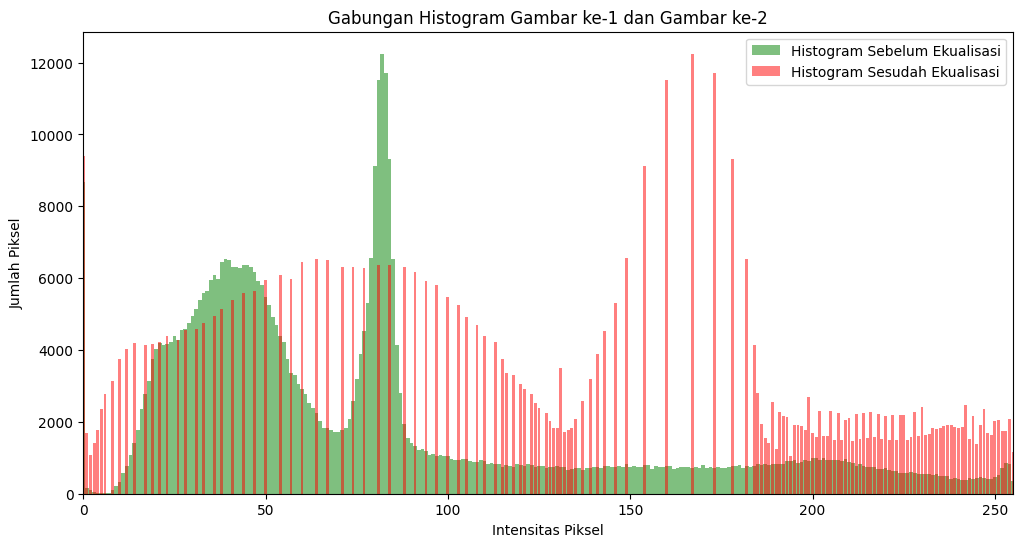

In [18]:
def hitung_histogram(gambar):

    img_arr = np.array(gambar).astype(float)

    # grayscale luminance
    if len(img_arr.shape) == 3:     # len = length yaitu panjang
        img_arr = (
            0.299 * img_arr[:,:,0] +
            0.587 * img_arr[:,:,1] +
            0.114 * img_arr[:,:,2]
        )
    # NORMALISASI BALIK: Jika nilai piksel masih 0-1, kalikan ke 0-255
    if img_arr.max() <= 1.1:
        img_arr = img_arr * 255

    piksel_flat = img_arr.flatten()

    # WADAH: Menyiapkan list berisi nol sebanyak 256 slot (untuk warna 0-255)
    histogram = [0] * 256

    for p in piksel_flat:
        p = int(round(p))
        if 0 <= p <= 255:
            histogram[p] += 1
    return histogram

sebelum = hitung_histogram(gabung)
sesudah = hitung_histogram(hasil)

x = np.arange(256)

plt.figure(figsize=(12,6))

plt.bar(
    x,
    sebelum,
    width=1.0,
    color='green',
    alpha=0.5,
    label='Histogram Sebelum Ekualisasi'
)

plt.bar(
    x,
    sesudah,
    width=0.8,
    color='red',
    alpha=0.5,
    label='Histogram Sesudah Ekualisasi'
)

plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')

plt.xlim(0,255)
plt.legend()
plt.show()

### Analisis
gambar di atas adalah tampilan hasil histogram di mana yang warna merah adalah histogram sebelum ekualisasi, sedangkan histogram yang berwarna hijau adalah histogram setelah di ekualisasi, sebelumnya histogram yng warna merah tu masih tidak rata, dengan intensitas piksel pada 150 sampai kurang dari 200 itu mengalami peningkatan yang cukup drastis, dan tidak merata, tidak di bagi rata menandakan bahwa citra asli memiliki kontras yang rendah atau didominasi oleh rentang pencahayaan yang sempit. Setelah dilakukan ekualisasi histogram (grafik merah), distribusi jumlah piksel melebar secara masif dan mengisi hampir seluruh rentang nilai intensitas dari 0 hingga 255 secara lebih seragam.

### Tampilkan histogram citra Windut dan citra bunga ireng
proses berikut ini adalah mengubah citra asli (RGB) menjadi citra grayscale menggunakan fungsi cv2.cvtColor, dengan mengubah format warna ke derajat keabuan.

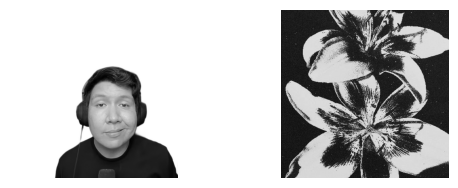

In [19]:
windut = cv.imread("Assets/Windut.png")
bunga = cv.imread("Assets/Bunga.png")

windut1 = cv.cvtColor(windut, cv.COLOR_BGR2GRAY)
bunga1 = cv.cvtColor(bunga, cv.COLOR_BGR2GRAY)

plt.subplot(2,2,1)
plt.axis('off')
plt.imshow(windut1, cmap='gray')

plt.subplot(2,2,2)
plt.axis('off')
plt.imshow(bunga1, cmap='gray')

### Hasil spesifikasi 
Spesifikasi histogram (atau histogram matching) adalah teknik manipulasi citra yang bertujuan untuk mengubah distribusi warna citra asal agar menyerupai karakteristik visual dari citra target. Melalui pemetaan fungsi distribusi kumulatif (CDF), piksel pada citra asal dimodifikasi sehingga hasil akhirnya memiliki nuansa pencahayaan, kontras, dan kecerahan yang serupa dengan citra referensi tanpa mengubah struktur konten aslinya. Intinya, jika citra asal terlalu terang dan citra target memiliki nada yang lebih gelap dan artistik, teknik ini secara otomatis "memaksa" citra asal untuk mengadopsi suasana gelap tersebut dengan mencocokkan profil histogram keduanya.

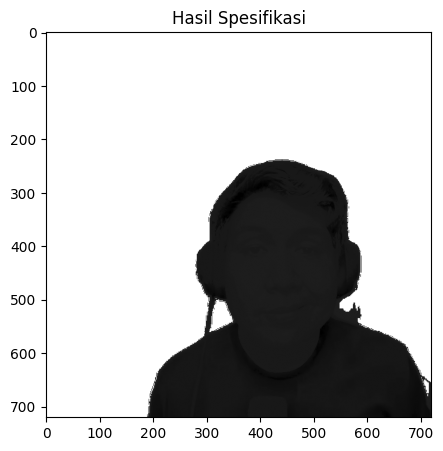

In [20]:
def spesifikasi_histogram(citra_asal, citra_target):

    hist_asal = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    # Histogram citra asal
    for y in range(citra_asal.shape[0]):
        for x in range(citra_asal.shape[1]):
            pixel = citra_asal[y, x]
            hist_asal[pixel] += 1

    # Histogram citra target
    for y in range(citra_target.shape[0]):
        for x in range(citra_target.shape[1]):
            pixel = citra_target[y, x]
            hist_target[pixel] += 1

    # Membuat CDF
    cdf_asal = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    # Hitung CDF
    for i in range(1, 256):
        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]
        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    # Normalisasi
    cdf_asal = cdf_asal / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    # Mapping histogram
    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        min_selisih = abs(cdf_asal[i] - cdf_target[0])
        indeks = 0
        for j in range(1, 256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < min_selisih:
                min_selisih = selisih
                indeks = j
        map_hist[i] = indeks

    # Terapkan mapping
    height, width = citra_asal.shape

    hasil = np.zeros((height, width), dtype=np.uint8)

    for y in range(height):
        for x in range(width):
            pixel = citra_asal[y, x]
            hasil[y, x] = map_hist[pixel]
    return hasil

hasil_spesifikasi = spesifikasi_histogram(windut1, bunga1)

plt.figure(figsize=(12,5))

plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.show()

### spesifikasi citra Windut dengan citra bunga ireng
Grafik ini menampilkan sebelum di lakukannya manipulasi. Histogram berwarna hijau (Windut) dan merah (Bunga) mewakili distribusi intensitas asli mereka, kedua citra memiliki karakteristik pencahayaan, kontras, dan kecerahan yang berbeda secara signifikan. Intinya, grafik ini berfungsi sebagai data pembanding untuk membuktikan bahwa setiap citra memiliki distribusi piksel unik yang tidak seragam satu sama lain.

Text(0, 0.5, 'Jumlah Pixel')

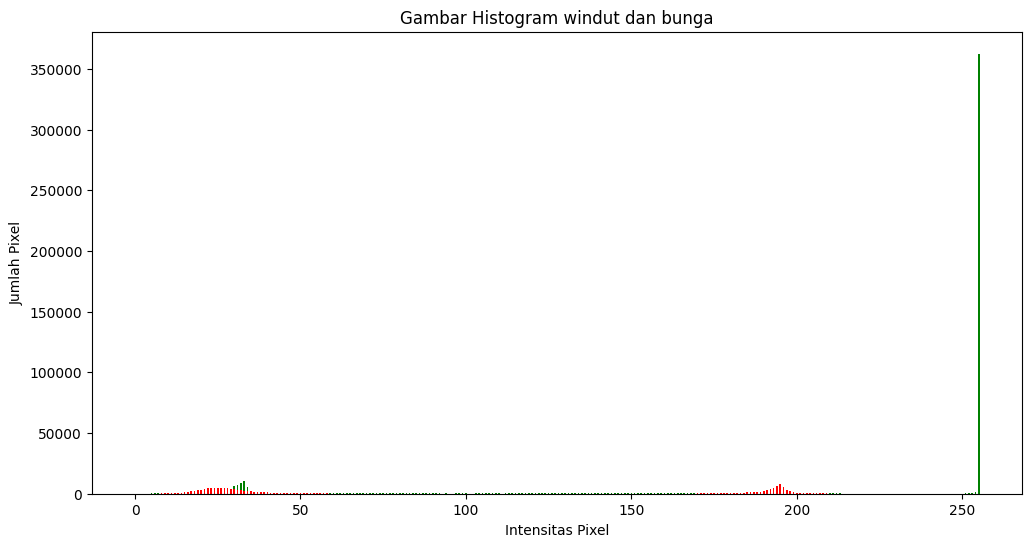

In [21]:
sebelum = hitung_histogram(windut1)
sesudah = hitung_histogram(bunga1)

plt.figure(figsize=(12, 6))

plt.bar(range(256), sebelum, width=0.5, color='green') # sebelum di tambahkan atribut
plt.bar(range(256), sesudah, width=0.5, color='red') # setelah di tambahkan atribut

plt.title('Gambar Histogram windut dan bunga')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')

Grafik ini menunjukkan bahwa distribusi intensitas citra hasil telah berhasil dimodifikasi mengikuti pola citra target. Intinya, perubahan sebaran histogram ini membuktikan bahwa citra asli telah mengadopsi karakteristik kontras dan pencahayaan yang baru melalui proses spesifikasi.

Text(0, 0.5, 'Jumlah Pixel')

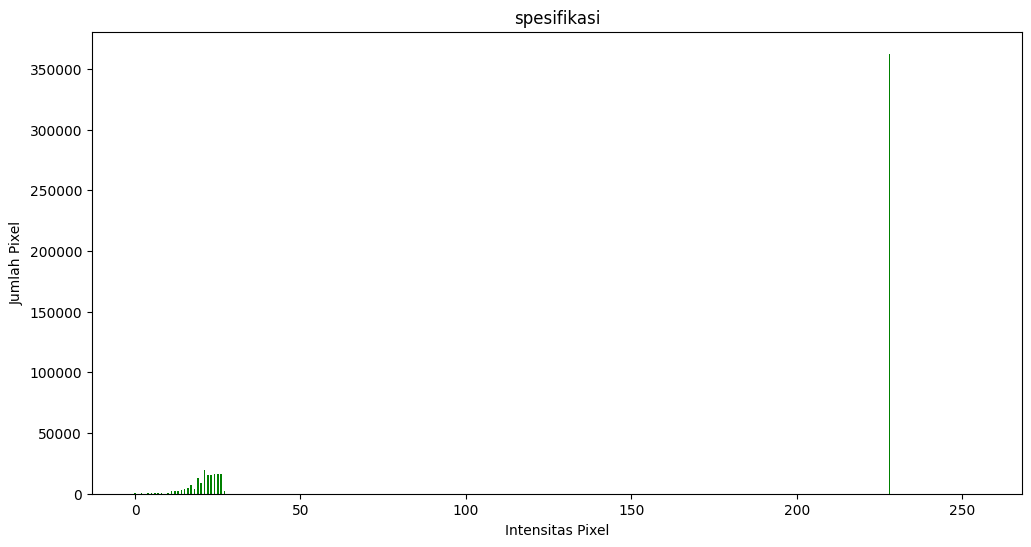

In [22]:
sebelum = hitung_histogram(hasil_spesifikasi)

plt.figure(figsize=(12, 6))

plt.bar(range(256), sebelum, width=0.5, color='green') # sebelum di tambahkan atribut

plt.title('spesifikasi')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')

### Proses Masking
proses yang memanfaatkan perbedaan intensitas cahaya untuk memisahkan objek dari latar belakangnya. Dengan menerapkan ambang batas (threshold) pada nilai piksel citra hasil spesifikasi, kode ini secara selektif mempertahankan detail terang dari citra asli sebagai latar belakang namun memaksa area gelap atau siluet menjadi hitam pekat (nol)

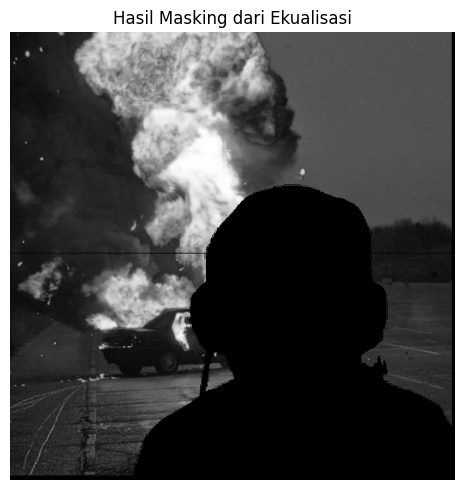

In [23]:
# Konversi cg1 ke uint8 
if gc1.max() <= 1.0:
    cg1_uint8 = (gc1 * 255).astype(np.uint8)
else:
    cg1_uint8 = gc1.astype(np.uint8)

# CROPPING 
min_tinggi = min(cg1_uint8.shape[0], hasil_spesifikasi.shape[0])
min_lebar  = min(cg1_uint8.shape[1], hasil_spesifikasi.shape[1])

cg1_crop   = cg1_uint8[:min_tinggi, :min_lebar]
ekual_crop = hasil_spesifikasi[:min_tinggi, :min_lebar]

# MASKING (dibalik)
hasil_masking = np.zeros_like(cg1_crop, dtype=np.uint8)

for i in range(min_tinggi):
    for j in range(min_lebar):
        if ekual_crop[i, j] > 100:       # background/langit terang → ambil dari gc1 (Meledak)
            hasil_masking[i, j] = cg1_crop[i, j]
        else:                             # siluet orang gelap → hitam
            hasil_masking[i, j] = 0

plt.figure(figsize=(5, 5))
plt.imshow(hasil_masking, cmap='gray')
plt.title('Hasil Masking dari Ekualisasi')
plt.axis('off')
plt.tight_layout()
plt.show()

### Penggabungan citra dengan menempelkan objek utama ke background
Peoses dengan memanfaatkan hasil spesifikasi histogram sebagai panduan masking untuk menggabungkan dua citra yang berbeda. Proses diawali dengan menyelaraskan dimensi ketiga citra melalui cropping agar setiap piksel memiliki koordinat yang sinkron. Intinya, algoritma menggunakan ambang batas pada citra hasil ekualisasi/spesifikasi untuk memisahkan latar belakang dan objek area yang terdeteksi sebagai latar belakang terang (> 200) diisi oleh citra "Meledak", sementara area objek gelap dipertahankan dari citra "Windut" asli, sehingga menciptakan satu kesatuan citra baru yang menggabungkan elemen visual dari kedua sumber tersebut.

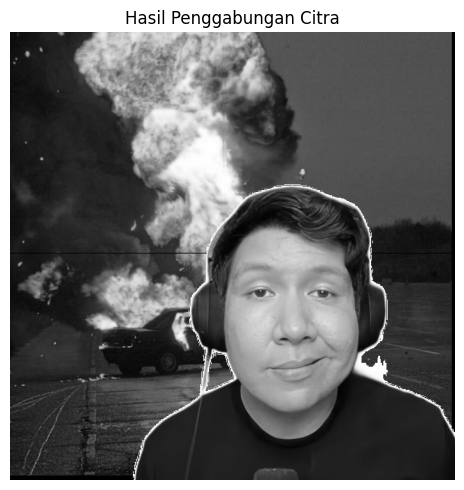

In [ ]:
# CROPPING semua gambar ke dimensi terkecil
min_tinggi = min(cg1_uint8.shape[0], hasil_spesifikasi.shape[0], windut1.shape[0])
min_lebar  = min(cg1_uint8.shape[1], hasil_spesifikasi.shape[1], windut1.shape[1])

cg1_crop    = cg1_uint8[:min_tinggi, :min_lebar]
ekual_crop  = hasil_spesifikasi[:min_tinggi, :min_lebar]
windut_crop = windut1[:min_tinggi, :min_lebar]

# ── 3. PENGGABUNGAN dengan perulangan
hasil_gabung = np.zeros_like(cg1_crop, dtype=np.uint8)

for i in range(min_tinggi):
    for j in range(min_lebar):
        # Area putih (background windut) → ganti dengan Meledak
        if ekual_crop[i, j] > 200:
            hasil_gabung[i, j] = cg1_crop[i, j]
        # Area gelap (objek orang) → ambil dari windut1 ASLI
        else:
            hasil_gabung[i, j] = windut_crop[i, j]

plt.figure(figsize=(5, 5))
plt.imshow(hasil_gabung, cmap='gray')
plt.title('Hasil Penggabungan Citra')
plt.axis('off')
plt.tight_layout()
plt.show()

### Hasil Akhir - Windut Tampil Ganteng
Proses ini merupakan tahap final yang bertujuan menyelaraskan suasana visual citra hasil penggabungan dengan citra langit. Melalui spesifikasi histogram, distribusi intensitas pada hasil_gabung dipetakan ulang agar mengikuti profil pencahayaan dan kontras dari langit_gray. Teknik ini memastikan objek dan latar belakang yang sebelumnya digabungkan secara manual kini memiliki keselarasan warna dan pencahayaan yang konsisten, sehingga citra akhir terlihat lebih menyatu secara natural dan estetis.

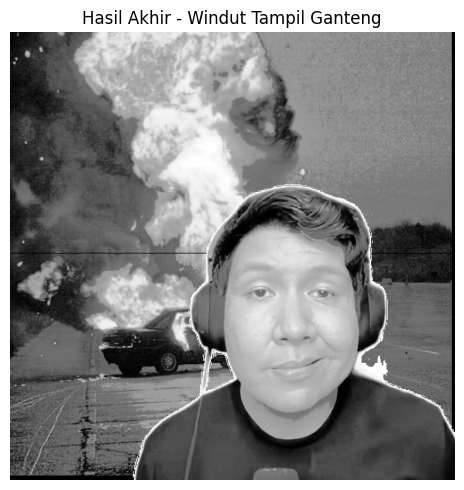

In [ ]:
# Load gambar langit & konversi ke grayscale
langit = plt.imread("Assets/Langit.png") 

if len(langit.shape) == 3:
    langit_gray = (0.299 * langit[:,:,0] + 0.587 * langit[:,:,1] + 0.114 * langit[:,:,2])
    if langit_gray.max() <= 1.0:
        langit_gray = (langit_gray * 255).astype(np.uint8)
    else:
        langit_gray = langit_gray.astype(np.uint8)
else:
    langit_gray = langit.astype(np.uint8)


# Spesifikasi histogram hasil_gabung → langit_gray 
hasil_akhir = spesifikasi_histogram(hasil_gabung, langit_gray)

plt.figure(figsize=(5, 5))
plt.imshow(hasil_akhir, cmap='gray')
plt.title('Hasil Akhir - Windut Tampil Ganteng')
plt.axis('off')
plt.tight_layout()
plt.show()

### Spesifikasi windut dengan langit

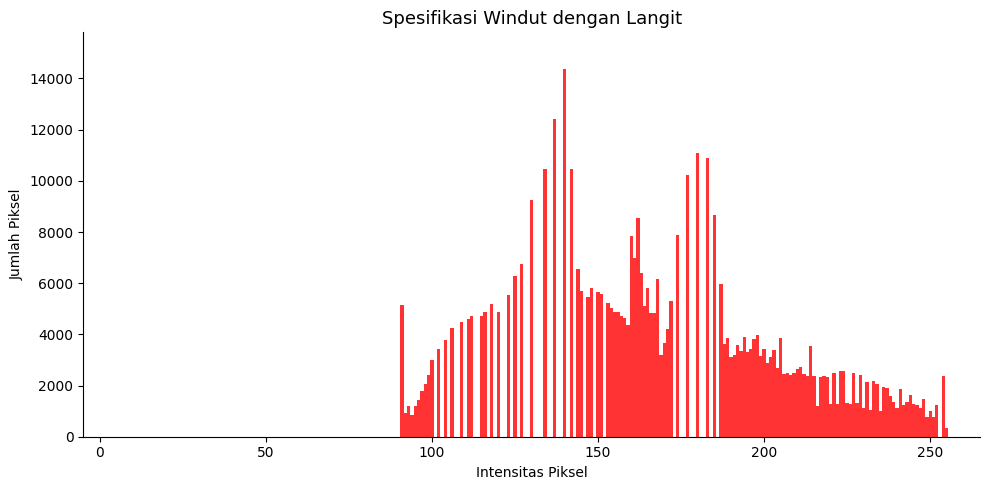

In [ ]:
hist_akhir = hitung_histogram(hasil_akhir)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(range(256), hist_akhir, width=1.0, color='red', alpha=0.8)

ax.set_title('Spesifikasi Windut dengan Langit', fontsize=13)
ax.set_xlabel('Intensitas Piksel')
ax.set_ylabel('Jumlah Piksel')
ax.set_xlim(-5, 265)
ax.set_ylim(0, max(hist_akhir) * 1.1)

# Garis border hanya bawah dan kiri (seperti referensi)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Berdasarkan hasil pada grafik di atas, "Spesifikasi Windut dengan Langit" menunjukkan distribusi histogram hasil pemetaan spesifikasi citra yang condong ke arah rentang nilai intensitas menengah hingga tinggi (terang). Pada grafik tersebut, terlihat jelas bahwa area intensitas rendah atau gelap dari nilai 0 hingga sekitar 90 sama sekali tidak memiliki piksel (kosong), yang menandakan citra akhir ini kehilangan komponen bayangan atau warna hitam pekat. Distribusi piksel baru mulai muncul dengan lonjakan awal di nilai intensitas dekat 90, frekuensi utama yang dominan di sekitar nilai intensitas 140 dan 180, sebelum akhirnya melandai secara bertahap hingga menyentuh batas nilai 255. Pola persebaran yang terkonsentrasi di area tengah ke kanan ini mengindikasikan bahwa citra akhir memiliki karakteristik visual yang cenderung terang dan didominasi oleh warna-warna berintensitas medium hingga cerah, yang secara fungsional sesuai dengan target pembentukan elemen langit atau area latar yang terang.

### Membuat windut dan backgroundnya berwarna
Kode ini digunakan untuk menggabungkan dua gambar berwarna (Windut dan background) dengan teknik masking warna putih, sehingga bagian putih pada objek diganti dengan background.
Proses dimulai dengan standarisasi format kedua citra ke dalam ruang warna RGB dan tipe data uint8, diikuti dengan penyelarasan ukuran melalui pemotongan (cropping) agar dimensi keduanya identik. Intinya, algoritma melakukan pemindaian piksel demi piksel di mana setiap area pada objek yang memiliki intensitas warna mendekati putih sempurna (> 245) akan dianggap transparan dan digantikan oleh piksel dari citra latar belakang, sehingga menghasilkan komposisi visual yang menyatu secara utuh.

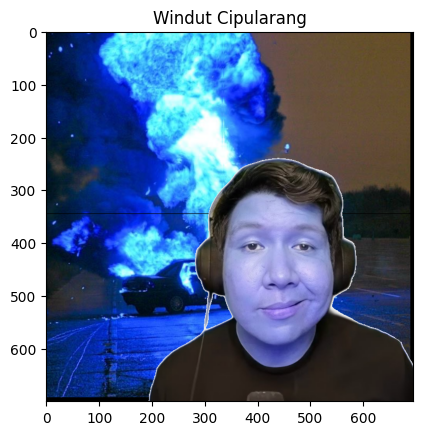

In [ ]:
windut_color = cv.imread('Assets/Windut.png')

background_color = merge.copy()
if len(background_color.shape) == 3:
    background_color = background_color[:, :, :3][:, :, ::-1] 

if len(background_color.shape) == 2:
    background_color = np.stack((background_color,) * 3, axis=-1)

if background_color.max() <= 1.0:
    background_color = (background_color * 255).astype(np.uint8)

background_color = background_color.astype(np.uint8)

h_bg, w_bg, _ = background_color.shape
h_w, w_w, _ = windut_color.shape

h_min = min(h_bg, h_w)
w_min = min(w_bg, w_w)

background_crop = background_color[0:h_min, 0:w_min]
windut_crop = windut_color[0:h_min, 0:w_min]

hasil = np.zeros((h_min, w_min, 3), dtype=np.uint8)

batas_putih = 245

for y in range(h_min):
    for x in range(w_min):
        b = windut_crop[y, x, 0]
        g = windut_crop[y, x, 1]
        r = windut_crop[y, x, 2]
        
        if not (b > batas_putih and g > batas_putih and r > batas_putih):
            hasil[y, x] = windut_crop[y, x]
        else:
            hasil[y, x] = background_crop[y, x]

plt.imshow(hasil)
plt.title("Windut Cipularang")
plt.show()